In [1]:
# Core
import json
import re
from collections import Counter
from tqdm import tqdm

# Data
import pandas as pd
import numpy as np

# NLP
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from rake_nltk import Rake
from sentence_transformers import SentenceTransformer

# ML / viz
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Download resources
nltk.download("punkt")
nltk.download("stopwords")

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words("english"))
sns.set(style="whitegrid")


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/fatirqureshi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/fatirqureshi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
import requests

url = "https://huggingface.co/datasets/garethpaul/children-stories-dataset/resolve/main/train.jsonl"
r = requests.get(url)

with open("train.jsonl", "wb") as f:
    f.write(r.content)

stories = []
with open("train.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f, start=1):
        try:
            stories.append(json.loads(line))
        except json.JSONDecodeError:
            print(f"Skipping malformed line {i}")

print(f"Loaded {len(stories)} stories")


Loaded 9970 stories


In [5]:
def extract_characters(text, top_n=5):
    doc = nlp(text)
    people = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
    return [p for p, _ in Counter(people).most_common(top_n)]

def extract_nouns(text):
    doc = nlp(text)
    return list({
        t.text.lower()
        for t in doc
        if t.pos_ in ("NOUN", "PROPN") and t.text.lower() not in stop_words
    })

def extract_themes(text, top_n=5):
    rake = Rake(stopwords=stop_words)
    rake.extract_keywords_from_text(text)
    return rake.get_ranked_phrases()[:top_n]

def create_feature_text_safe(story):
    text = story.get("text", "").strip()
    if not text:
        return "No content"

    chars = extract_characters(text)
    nouns = extract_nouns(text)
    themes = extract_themes(text)

    features = []
    if chars:
        features.append("characters: " + ", ".join(chars))
    if nouns:
        features.append("nouns: " + ", ".join(nouns))
    if themes:
        features.append("themes: " + ", ".join(themes))

    return " | ".join(features) if features else text[:300]


In [31]:
def get_tokens(text):
    return [t for t in word_tokenize(text) if t.isalpha()]

def story_stats(text):
    tokens = get_tokens(text.lower())
    num_tokens = len(tokens)
    num_types = len(set(tokens))
    ttr = num_types / num_tokens if num_tokens else 0
    num_sents = len(sent_tokenize(text))
    return num_tokens, num_types, ttr, num_sents


In [33]:
IMPERATIVE_VERBS = {
    "do", "make", "put", "take", "add", "mix", "build", "draw",
    "write", "read", "cut", "fold", "place", "use", "start",
    "begin", "finish", "repeat", "follow"
}

STEP_MARKERS = {
    "first", "second", "third", "next", "then", "finally",
    "step", "step-by-step"
}

GOAL_PHRASES = {
    "how to", "in order to", "to make", "to build", "to do"
}


In [35]:
def instructional_score(text, nlp):
    text_lc = text.lower()
    doc = nlp(text)

    # 1. Imperative verbs (VB at sentence start, no subject)
    imperative_count = 0
    for sent in doc.sents:
        tokens = list(sent)
        if tokens and tokens[0].pos_ == "VERB":
            imperative_count += 1

    # 2. Second-person or generic agent
    second_person = sum(t.text.lower() in {"you", "your", "we"} for t in doc)

    # 3. Step structure markers
    step_hits = sum(m in text_lc for m in STEP_MARKERS)

    # 4. Goal framing
    goal_hits = sum(p in text_lc for p in GOAL_PHRASES)

    # 5. Named character penalty
    char_count = sum(ent.label_ == "PERSON" for ent in doc.ents)

    # 6. Verb density
    num_verbs = sum(t.pos_ == "VERB" for t in doc)
    num_nouns = sum(t.pos_ in {"NOUN", "PROPN"} for t in doc)
    verb_noun_ratio = num_verbs / (num_nouns + 1)

    # Weighted score
    score = (
        2.5 * imperative_count +
        1.5 * second_person +
        2.0 * step_hits +
        2.0 * goal_hits +
        1.5 * verb_noun_ratio -
        1.0 * char_count
    )

    return score


In [37]:
def is_instructional(text, nlp, threshold=5.0):
    return instructional_score(text, nlp) >= threshold


In [41]:
def topic_proxies(text):
    has_number = bool(re.search(r"\d", text))

    doc = nlp(text)
    char_names = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]

    instr_score = instructional_score(text, nlp)
    has_instructions = instr_score >= 5.0

    return (
        has_number,
        "; ".join(char_names[:5]),
        has_instructions,
        instr_score
    )


In [43]:
records = []

for s in tqdm(stories):
    text = s.get("text", "")

    L, U, TTR, S = story_stats(text)
    hn, cn, hi = topic_proxies(text)

    records.append({
        "title": s.get("title", ""),
        "text": text,
        "num_tokens": L,
        "num_types": U,
        "ttr": TTR,
        "num_sents": S,
        "has_number": hn,
        "char_names": cn,
        "has_instructions": hi,
        "feature_text": create_feature_text_safe(s)
    })

df = pd.DataFrame(records)
df.head()


  0%|                                                  | 0/9970 [00:00<?, ?it/s]


ValueError: too many values to unpack (expected 3)

In [45]:
df["length_bin"] = pd.qcut(
    df["num_tokens"],
    q=3,
    labels=["short", "medium", "long"]
)


In [47]:
df["complexity_bin"] = pd.qcut(
    df["ttr"],
    q=3,
    labels=["simple", "moderate", "complex"]
)


In [49]:
def topic_bucket(row):
    if row["has_instructions"]:
        return "instructional"
    if row["has_number"]:
        return "numeric/educational"
    if row["char_names"]:
        return "character-driven"
    return "other"

df["topic_bucket"] = df.apply(topic_bucket, axis=1)


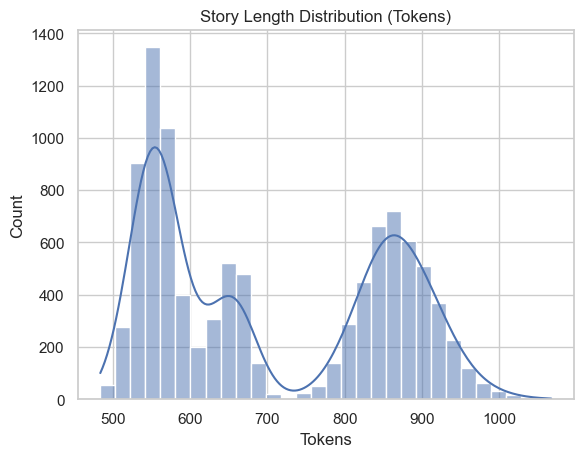

In [51]:
sns.histplot(df["num_tokens"], bins=30, kde=True)
plt.title("Story Length Distribution (Tokens)")
plt.xlabel("Tokens")
plt.ylabel("Count")
plt.show()


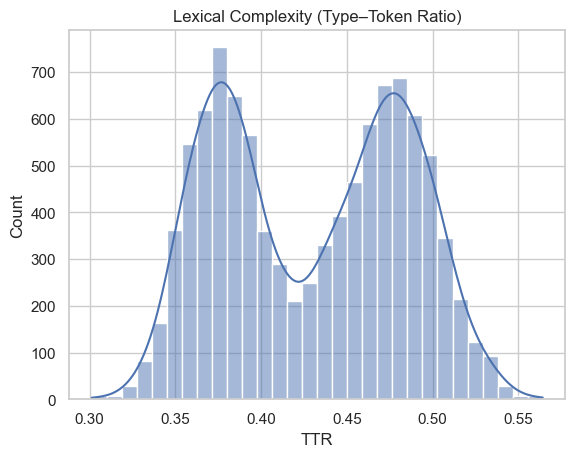

In [21]:
sns.histplot(df["ttr"], bins=30, kde=True)
plt.title("Lexical Complexity (Type–Token Ratio)")
plt.xlabel("TTR")
plt.ylabel("Count")
plt.show()


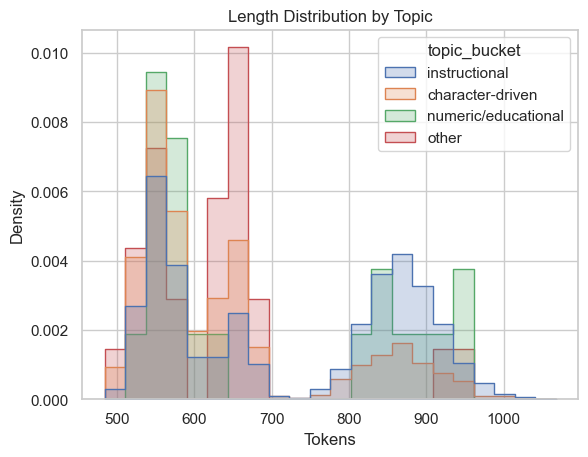

In [23]:
sns.histplot(
    data=df,
    x="num_tokens",
    hue="topic_bucket",
    stat="density",
    element="step",
    common_norm=False
)
plt.title("Length Distribution by Topic")
plt.xlabel("Tokens")
plt.show()


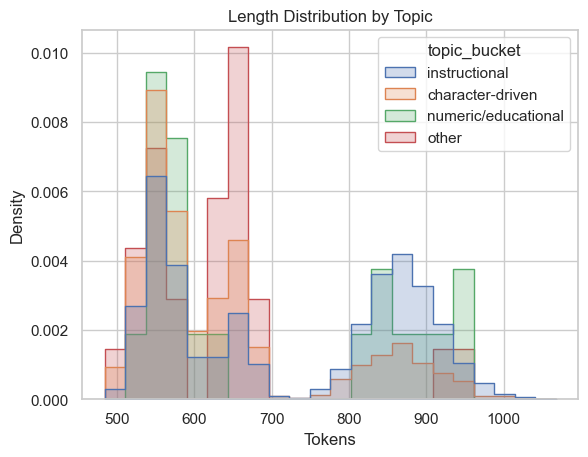

In [25]:
sns.histplot(
    data=df,
    x="num_tokens",
    hue="topic_bucket",
    stat="density",
    element="step",
    common_norm=False
)
plt.title("Length Distribution by Topic")
plt.xlabel("Tokens")
plt.show()


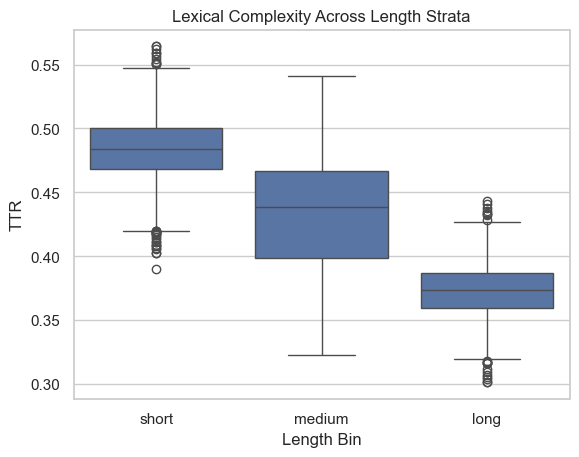

In [27]:
sns.boxplot(data=df, x="length_bin", y="ttr")
plt.title("Lexical Complexity Across Length Strata")
plt.xlabel("Length Bin")
plt.ylabel("TTR")
plt.show()


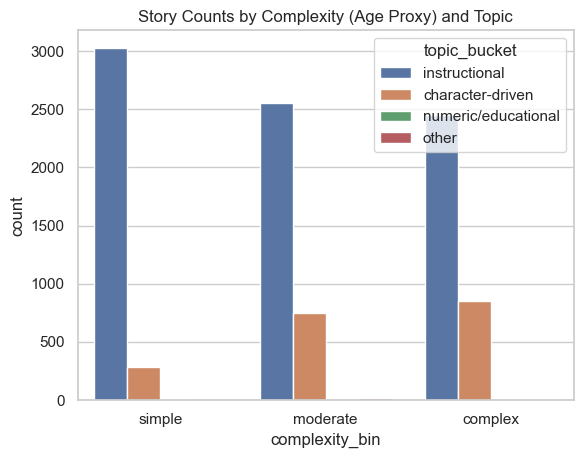

In [29]:
sns.countplot(data=df, x="complexity_bin", hue="topic_bucket")
plt.title("Story Counts by Complexity (Age Proxy) and Topic")
plt.show()
